<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/ADPs/Lecture_5/Raw/Lecture%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекция №5: Современные NLP-модели: от BERT до LLM

---

## 1. ВВЕДЕНИЕ

**От слов к смыслу: эволюция NLP**

Представьте себе такую ситуацию. Вы — клинический психолог, и пациент говорит вам: *«Я чувствую себя пустым. Ничего не радует. Всё кажется бессмысленным.»* Вы мгновенно понимаете: это маркеры депрессии, ангедония, снижение настроения. Вы связываете эти слова в единую картину, видите контекст, улавливаете оттенки смысла.

А теперь представьте, что эти же слова попадают в компьютер, который использует **мешок слов** (Bag of Words, из Лекции 3). Что он увидит? Просто набор слов: *«чувствую»*, *«пустым»*, *«ничего»*, *«радует»*, *«кажется»*, *«бессмысленным»*. Он посчитает частоты, но **не увидит связи** между ними. Для него фраза *«ничего не радует»* и *«радует не ничего»* будут почти одинаковыми — хотя смысл кардинально разный!

Именно эту проблему решают современные NLP-модели. Они **понимают контекст**, **учитывают порядок слов** и **извлекают смысл** из текста так, как это делает опытный клиницист.

> **Ключевой пример из психологии:**
> Фраза *«я хочу умереть»* и *«я хочу жить»* отличаются всего одним словом, но для психолога это два абсолютно разных состояния. Традиционные методы (мешок слов) увидят только разницу в частотах. Современные модели (BERT, GPT) «поймут» разницу в смысле, потому что они учитывают контекст всего предложения.

Исследования показывают, что трансформерные модели значительно превосходят традиционные подходы благодаря способности улавливать контекстуальные и семантические связи в тексте. Например, BERT достигает точности **93%** при обнаружении эмоционального дистресса, а современные открытые LLM (Gemma-3-27B, Llama-3.3-70B) показывают F1-score **0.818–0.865** при дообучении на клинических данных для скрининга депрессии [5].

---

### Почему это критически важно для психолога?

| Что дают современные модели | Как это помогает в практике |
|-----------------------------|------------------------------|
| **Извлечение симптомов** | Автоматически выделяют ключевые симптомы из терапевтических диалогов и протоколов |
| **Анализ динамики** | Отслеживают изменения в языке пациента в ходе терапии |
| **Оценка рисков** | Выявляют суицидальные маркеры и другие тревожные сигналы |
| **Поиск похожих случаев** | Находят в базе аналогичные клинические случаи для сравнения терапии |
| **Генерация отчётов** | Создают краткие резюме длинных историй болезни |

---

### Как мы будем двигаться по лекции



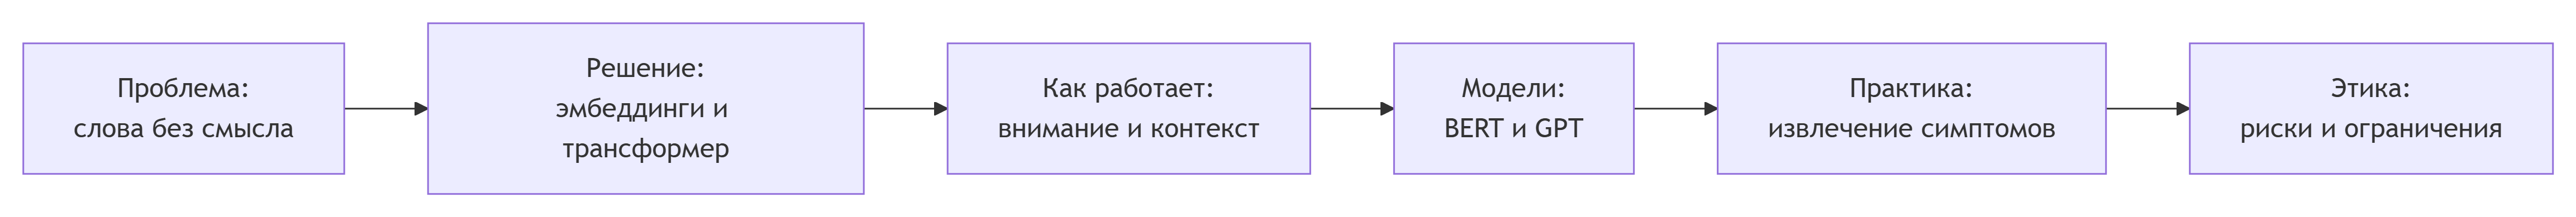



### Связь с предыдущими лекциями

- **Лекция 3** — мы научились **готовить текст** для модели (очистка, токенизация, лемматизация, мешок слов).
- **Лекция 4** — мы научились **визуализировать** результаты работы моделей.
- **Сегодня** — мы узнаем, как модели **«думают»** и что они могут дать практике.

---

### Этический контекст (кратко)

Прежде чем мы погрузимся в технические детали, важно помнить: модели могут ошибаться. Они могут **галлюцинировать** — выдавать информацию, которой нет в данных. Они могут быть **предвзятыми**, если обучались на данных со стереотипами. И они могут **нарушать конфиденциальность**, если используются без должной защиты. Поэтому их применение в клинической практике требует **критического мышления**, **человеческого контроля** и **прозрачности**.

---

**Ключевая мысль:** современные NLP-модели — это не просто «умные счётчики слов». Это инструменты, которые пытаются **понять пациента** так, как это делает психолог, но с помощью чисел и алгоритмов. И как любой инструмент, они требуют ответственного использования.




## 2. КАК МОДЕЛИ РАБОТАЮТ С ТЕКСТОМ: ОТ СЛОВ К ЧИСЛАМ

Прежде чем погружаться в архитектуру трансформера, давайте разберёмся **с чем именно работает модель** и как текст превращается в числа, которые модель может обрабатывать. Это основа, без которой невозможно понять всё остальное.

---

### 2.1. Векторное представление слов (Word Embeddings)

**Что это:** каждое слово превращается в **вектор** — список чисел (обычно 100–768 чисел на одно слово). Это как «цифровой паспорт» слова.

**Интуитивная аналогия из психологии:**

> Представьте, что вы описываете пациента по множеству параметров: возраст, уровень тревоги, качество сна, социальная активность, семейный статус, образование... Вы создаёте «числовой портрет» пациента. То же самое модель делает со словами — только параметров у неё сотни, и они отражают не демографию, а **смысловые отношения** между словами.

**Ключевое свойство эмбеддингов:** слова со схожим смыслом оказываются **рядом** в этом пространстве.

> **Пример:** в пространстве эмбеддингов:
> - *«тревога»* и *«страх»* — рядом (близкие по смыслу).
> - *«тревога»* и *«радость»* — далеко (противоположные по смыслу).
> - *«тревога»* и *«стул»* — очень далеко (несвязанные понятия).

**Как это помогает в психологии:** модель может «знать», что *«депрессия»* связана с *«безнадёжность»*, *«апатия»* и *«сон»*, даже если эти слова не встречались вместе в конкретном тексте пациента. Она «понимает» смысловые связи, как опытный клиницист.

---

### 2.2. Word2Vec: как слова обретают смысл

**Word2Vec** — это одна из первых и самых известных моделей для создания эмбеддингов слов, разработанная Google в 2013 году. Её ключевая идея проста: **значение слова определяется его окружением**.

**Интуитивная аналогия:**

> Представьте, что вы изучаете иностранный язык, читая тысячи текстов. Вы замечаете, что слова *«тревога»* и *«страх»* часто встречаются в одних и тех же предложениях (рядом с *«сердце»*, *«пот»*, *«беспокойство»*). Постепенно вы начинаете понимать, что эти слова связаны по смыслу. Word2Vec делает то же самое — но математически и в огромном масштабе.

**Как это работает (упрощённо):**

Модель «смотрит» на каждое слово и пытается предсказать слова вокруг него. Если модель угадывает — она «понимает» смысл. В процессе она создаёт векторы — числа, которые отражают эти смысловые связи.

---

### 2.3. Живой пример: находим семантических соседей

Давайте посмотрим, как это работает на практике с **предобученной русскоязычной моделью Word2Vec** (обучена на корпусе текстов из интернета и Википедии) [6†L4-L7].

**Код для демонстрации:**



In [ ]:

# Установка библиотеки (выполняется один раз)
!pip install gensim

import gensim.downloader as api

# Загружаем предобученную модель для русского языка
# Это как если бы мы взяли с полки готовый словарь ассоциаций
russian_model = api.load("word2vec-ruscorpora-300")

# ------------------------------------------------------------
# 1. ПОИСК СЕМАНТИЧЕСКИХ СОСЕДЕЙ
# ------------------------------------------------------------
# Находим 10 слов, наиболее близких по смыслу к слову «кошка»
similar_to_cat = russian_model.most_similar('кошка_NOUN')
print("Слова, близкие к 'кошка':")
for word, score in similar_to_cat:
    print(f"  {word} — {score:.3f}")





**Что мы видим:** модель «понимает», что *«кот»*, *«котенок»* и даже *«собака»* — семантически близки к *«кошка»* (это домашние животные). А *«мяукать»* — связано с действием, которое совершает кошка. **Числа (0.757, 0.726...) — это косинусное сходство**: чем ближе к 1, тем более похожи слова по смыслу.

**Психологический смысл этого примера:**
> Если модель «знает», что *«кошка»* близка к *«котенок»* и *«мяукать»*, то она также «знает», что *«депрессия»* близка к *«безнадёжность»*, *«апатия»* и *«тоска»*. Это позволяет модели улавливать клинически значимые ассоциации в текстах пациентов.

---

### 2.4. Сравнение семантической близости

Модель может вычислять **степень сходства** между любыми двумя словами:



In [ ]:
similar_words = [w for w in russian_model.key_to_index.keys() if w.startswith('мужчин')]
print(similar_words[:10])

# Проверяем наличие нужных слов с тегами
word1 = 'мужчина_NOUN'
word2 = 'женщина_NOUN'

if word1 in russian_model.key_to_index and word2 in russian_model.key_to_index:
    similarity = russian_model.similarity(word1, word2)
    print(f"Сходство между 'мужчина' и 'женщина': {similarity:.3f}")
else:
    print("Одно из слов с таким тегом отсутствует.")



**Что это даёт психологу:** можно количественно оценивать, насколько язык пациента «близок» к языку депрессии или тревоги, сравнивая средние расстояния между словами в его тексте и эталонными кластерами.

---

### 2.5. Поиск «лишнего» слова

Модель может находить слово, которое выбивается из смыслового ряда:



In [ ]:
# 3. ПОИСК ЛИШНЕГО СЛОВА
odd_word = russian_model.doesnt_match(
    ["завтрак_NOUN", "обед_NOUN", "ужин_NOUN", "хлопья_NOUN"]
)
print(f"Лишнее слово: {odd_word}")
# Вывод: хлопья_NOUN (потому что это не приём пищи)


**Психологическая аналогия:** это как если бы психолог заметил, что среди перечисленных симптомов (бессонница, потеря аппетита, апатия, радость) слово *«радость»* явно выбивается.

---

### 2.6. От статических эмбеддингов к контекстуальным

**Важное ограничение Word2Vec:** у слова *всегда один вектор*, независимо от контекста. Слово *«банк»* в предложениях *«я положил деньги в банк»* и *«я сидел на берегу банка»* получит **одинаковый** вектор. Это проблема!

**Решение:** современные модели (BERT, GPT) — **контекстуальные**. Они создают вектор для слова **с учётом всего предложения**. Поэтому *«банк»* в разных контекстах получает **разные** векторы.

**Интуитивная аналогия:**
> Word2Vec — это как психолог, который знает значение каждого слова из словаря, но не учитывает контекст. BERT — как опытный клиницист, который понимает, что слово *«тревога»* в фразе *«у меня была тревога, когда я потерял работу»* и *«тревога в отделении была высокой»* означает совершенно разные вещи.

---

### 2.7. Современные модели эмбеддингов 2025-2026 (доступные на Hugging Face)

Для работы с русским языком сегодня доступны десятки моделей, которые можно использовать «из коробки». Вот несколько примеров:

**Для сравнения семантической близости предложений (STS — Semantic Textual Similarity):**

| Модель | Размер эмбеддинга | Что умеет | Ссылка |
|--------|-------------------|-----------|--------|
| **rubert-large-uncased-sts** | 1024 | Оценка похожести русских предложений (STS, поиск парафраз) | sergeyzh/rubert-large-uncased-sts |
| **StaRSE** | 512 | Компактная модель для семантической близости, кластеризации, работает на CPU | BorisTM/starse |

**Пример использования rubert-large-uncased-sts:**




In [ ]:
from sentence_transformers import SentenceTransformer

# Загружаем модель для сравнения предложений
model = SentenceTransformer('sergeyzh/rubert-large-uncased-sts')

# Три предложения: два похожих и одно другое
sentences = [
    "Пациент сообщил о сильной тревоге и нарушении сна.",
    "Больной жалуется на беспокойство и проблемы со сном.",
    "Сегодня на улице хорошая погода."
]

# Получаем векторы (эмбеддинги) для всех предложений
embeddings = model.encode(sentences)

# Сравниваем все предложения попарно
similarities = model.similarity(embeddings, embeddings)
print("Матрица сходства:")
print(similarities)



**Что мы видим:** модель «понимает», что первые два предложения говорят об одном и том же (тревога и нарушение сна), а третье — о погоде.

**Психологический смысл:** такая модель может автоматически находить в базе протоколов похожие клинические случаи. Например, если у вас есть новый пациент с жалобами на тревогу и бессонницу, модель найдёт другие протоколы с похожими симптомами — для сравнения терапии и прогнозов.

---

### 2.8. Визуализация: как слова «живут» в пространстве

```mermaid
flowchart LR
    subgraph Пространство["🧠 Пространство эмбеддингов (упрощённо)"]
        direction TB
        T1["тревога"]
        T2["страх"]
        T3["беспокойство"]
        D1["депрессия"]
        D2["тоска"]
        D3["апатия"]
        R1["радость"]
        R2["счастье"]
        N1["стул"]
        N2["стол"]
    end
    
    subgraph Кластеры["📊 Смысловые кластеры"]
        C1["Кластер 'тревога'<br>тревога, страх, беспокойство"]
        C2["Кластер 'депрессия'<br>депрессия, тоска, апатия"]
        C3["Кластер 'позитив'<br>радость, счастье"]
        C4["Кластер 'нейтральное'<br>стул, стол"]
    end
    
    Пространство --> Кластеры
```

**Что мы видим на схеме:**
- Слова с близким смыслом образуют **кластеры** (группы).
- Расстояние между кластерами отражает смысловую разницу.
- *«Тревога»* и *«депрессия»* — рядом, но не пересекаются (это разные, но связанные концепты).
- *«Радость»* — далеко от *«депрессии»* (противоположные понятия).
- *«Стул»* и *«стол»* — далеко от всех эмоциональных слов (нейтральные объекты).

---

### 2.9. Как это помогает психологу на практике

| Что умеет модель | Пример из практики |
|------------------|-------------------|
| **Находить семантических соседей** | Психолог вводит слово *«безнадёжность»*, модель выдаёт: *«отчаяние»*, *«пустота»*, *«апатия»* — помогает увидеть спектр переживаний пациента |
| **Сравнивать близость понятий** | Модель показывает, что *«тревога»* ближе к *«страх»* (0.85), чем к *«депрессия»* (0.45) — помогает дифференцировать состояния |
| **Искать похожие клинические случаи** | По одному протоколу модель находит другие с похожей симптоматикой — для сравнения терапии |
| **Отслеживать динамику** | Сравнивая эмбеддинги дневников пациента в начале и конце терапии, можно измерить «семантический сдвиг» — язык стал ближе к кластеру «позитив»? |
| **Выявлять скрытые ассоциации** | Если у пациента слово *«мать»* семантически близко к *«боль»* и *«страх»* (а не к *«тепло»* и *«забота»*), это может быть маркером травмы |

---

### 2.10. От эмбеддингов к трансформеру

Эмбеддинги (статичные или контекстуальные) — это **входные данные** для модели. Но сами по себе они не решают задач диагностики. Дальше в игру вступает **трансформер** — архитектура, которая обрабатывает эти векторы, уточняет их с помощью механизма внимания и выдаёт финальный результат (классификацию, генерацию, ответ на вопрос).

**Ключевая мысль для запоминания:**

> Word2Vec и подобные модели — это **словарь ассоциаций**. Они знают, какие слова близки по смыслу. BERT и GPT — это **читатели**, которые используют этот словарь, чтобы понять смысл **целого предложения или текста** пациента.

---

Этот раздел теперь даёт студентам **конкретное, осязаемое понимание** того, как модели работают со смыслом. Они могут сами запустить код и увидеть, что *«кошка»* действительно близка к *«котёнку»*, а *«тревога»* — к *«страху»*. А главное — они понимают, **как это применить в клинической практике**.



## 3. АРХИТЕКТУРА ТРАНСФОРМЕРА: ИНТУИТИВНОЕ ВВЕДЕНИЕ

Прежде чем говорить о конкретных моделях (BERT, GPT), нужно понять, что у них общего. Почти все современные NLP-модели построены на **архитектуре трансформера** (Transformer). Она была предложена в 2017 году в статье *«Attention is All You Need»* и стала революцией в обработке языка [1].

**Почему трансформер важен:**

До трансформера модели обрабатывали текст последовательно (слово за словом), как мы читаем книгу. Это было медленно и не позволяло улавливать долгосрочные зависимости (связи между словами, которые далеко друг от друга). Трансформер предложил **обрабатывать все слова одновременно** (параллельно), что ускорило обучение и улучшило понимание контекста.

---

### 3.1. Ключевая идея: механизм внимания (Attention)

**Интуитивная аналогия из психотерапии:**

Представьте, что психолог слушает пациента. Пациент говорит: *«Я пришёл к вам, потому что... ну... в последнее время мне очень тяжело... я не могу спать, постоянно думаю о работе, и мне кажется, что я никому не нужен...»*

На что психолог обращает внимание? Не на все слова одинаково. Он **фокусируется** на ключевых сигналах: *«тяжело»*, *«не могу спать»*, *«никому не нужен»*. Он **взвешивает** важность каждого слова: фраза *«я пришёл»* важна, но меньше, чем *«никому не нужен»* (это маркер депрессии). Он **связывает** слова между собой: *«не могу спать»* связано с *«тяжело»* и *«думаю о работе»*.

**Это и есть механизм внимания (Attention) в трансформере.** Модель:
- Смотрит на **все слова одновременно**.
- Вычисляет **веса важности** для каждого слова относительно других.
- Фокусируется на **ключевых смысловых связях**.

> **Пример:** в предложении *«пациент с депрессией сообщил о суицидальных мыслях»*, модель «заметит», что *«депрессией»* сильно связано с *«суицидальных»*, и даст этим словам высокий вес.

---

### 3.2. Само-внимание (Self-Attention) — внимание к контексту

Трансформер использует **само-внимание** (self-attention): каждое слово в предложении «смотрит» на все остальные слова, чтобы понять свой собственный смысл в контексте.

**Интуитивная аналогия:**

> Слово *«банк»* в предложении *«я положил деньги в банк»* и *«я сидел на скамейке у банка»* — это одно и то же слово, но смысл разный. Само-внимание позволяет модели «увидеть» окружающие слова и понять, что в первом случае речь о финансовом учреждении, а во втором — о береге реки.

**В психологическом тексте:**
> Слово *«тревога»* в предложении *«у меня была тревога, когда я потерял работу»* и *«тревога в отделении была высокой из-за карантина»* — разные контексты. Модель через само-внимание «понимает» разницу.

**Как это вычисляется (очень упрощённо):**

Для каждого слова модель вычисляет три вектора:
- **Query (запрос):** «что я ищу?»
- **Key (ключ):** «что у меня есть?»
- **Value (значение):** «что я передаю дальше?»

Затем для каждой пары слов вычисляется «оценка внимания» — насколько запрос одного слова соответствует ключу другого. Чем выше оценка, тем больше внимания модель уделяет этой паре.

---

### 3.3. Многоголовое внимание (Multi-Head Attention)

Модель не ограничивается одним «фокусом внимания». Она использует **несколько голов внимания параллельно** (обычно 8–16). Каждая голова ищет **разные типы связей**:
- Одна голова ищет грамматические связи (подлежащее-сказуемое).
- Другая — семантические (смысловые) связи.
- Третья — эмоциональные маркеры (если модель обучена на психологических текстах).

**Интуитивная аналогия:**

> В супервизорской группе несколько психологов слушают один и тот же случай. Один обращает внимание на эмоции пациента, другой — на семейную историю, третий — на телесные симптомы. Каждый видит что-то своё. Потом они собираются вместе и формируют целостную картину. Это и есть многоголовое внимание.

---

### 3.4. Позиционное кодирование (Positional Encoding)

Трансформер обрабатывает все слова одновременно, но **порядок слов важен**. Как модель «знает», какое слово за каким идёт?

**Решение:** модель добавляет к каждому слову **позиционный вектор** — специальную метку, которая кодирует его положение в предложении.

> **Техническое уточнение:** на самом деле это не просто порядковый номер (1, 2, 3), а сложный математический паттерн (синусоидальные функции), который позволяет модели различать не только порядок, но и расстояние между словами. Но для понимания сути достаточно аналогии с нумерацией карточек.

**Интуитивная аналогия:**

> Представьте, что вы читаете предложение, где все слова написаны на отдельных карточках, и вам нужно понять смысл. Если карточки перемешаны, смысл теряется. Но если на каждой карточке написан номер, вы можете восстановить порядок. Позиционное кодирование — это те самые номера.

---

### 3.5. Полный путь текста через трансформер

Теперь соберём всё вместе. Вот как текст проходит через трансформер:

```mermaid
flowchart TD
    A["📝 Исходный текст<br>«Я чувствую тревогу»"]
    
    B["🔤 Токенизация<br>['я', 'чувствую', 'тревогу']"]
    
    C["🔢 Векторы слов (Embeddings)<br>каждое слово → 300 чисел"]
    
    D["📍 Добавление позиции<br>вектор + позиция в предложении"]
    
    E["🧠 Слой 1: Внимание<br>каждое слово «смотрит» на другие"]
    
    F["🧠 Слой 1: Нейросеть<br>уточнение векторов"]
    
    G["🔁 Повтор 6-12 раз<br>каждый слой уточняет смысл"]
    
    H["🎯 Выходные векторы<br>слова в контексте всего предложения"]
    
    A --> B --> C --> D --> E --> F --> G --> H
    
    style A fill:#fff9c4,stroke:#f57f17
    style H fill:#c8e6c9,stroke:#2e7d32
```

**Что происходит на каждом шаге:**

1. **Токенизация:** текст разбивается на минимальные единицы.
2. **Векторы слов:** каждое слово получает «цифровой паспорт».
3. **Позиция:** добавляется информация о порядке слов.
4. **Внимание:** слова «общаются» друг с другом, вычисляя важность связей.
5. **Нейросеть:** каждый вектор уточняется через нейронную сеть.
6. **Повтор:** все шаги повторяются несколько раз, чтобы «глубже» понять смысл.
7. **Выход:** каждый токен теперь «понимает» контекст всего предложения.

---



## 4. ПРЕДОБУЧЕННЫЕ МОДЕЛИ: BERT И GPT

Трансформер — это архитектура (строительные леса). Конкретные модели (BERT, GPT) — это уже построенные здания, которые **обучены на огромных объёмах текстов**.

---

### 4.1. Что такое «предобучение» (Pre-training)?

**Интуитивная аналогия из психологии:**

> Представьте, что психолог получает базовое образование: 5–6 лет учится, читает тысячи книг, изучает теории, практикуется на учебных случаях. Это **предобучение**. После этого он приходит на работу и учится работать с конкретными пациентами — это **дообучение** (fine-tuning).

То же самое с NLP-моделями:
1. **Предобучение:** модель читает миллиарды текстов (Википедия, книги, статьи, форумы) и учится предсказывать слова, понимать контекст, улавливать связи. Это занимает недели и требует огромных вычислительных ресурсов.
2. **Дообучение (fine-tuning):** модель адаптируется под конкретную задачу (например, диагностика депрессии) на специальном размеченном наборе данных. Это занимает часы и доступно даже на обычном компьютере.

**Почему это гениально:** вместо того чтобы учить модель с нуля для каждой задачи (что дорого и долго), мы берём уже «образованного помощника» и просто «показываем ему специфику» психиатрии.

---

### 4.2. BERT (Bidirectional Encoder Representations from Transformers)

**Что это:** модель, разработанная Google в 2018 году [2]. Она **читает текст целиком** (слева направо и справа налево) и понимает контекст каждого слова с обеих сторон.

**Ключевая особенность:** BERT — **двунаправленный** (bidirectional). Он учитывает слова, которые стоят **до и после** целевого слова.

**Интуитивная аналогия:**

> Психолог слушает пациента и понимает смысл его слов не только из того, что он сказал до этого, но и из того, что он скажет дальше. BERT работает так же: чтобы понять слово *«депрессия»*, он смотрит и на предыдущие слова, и на последующие.

**Пример из психологии:**

> **Текст:** *«Пациент сообщил о сильной [MASK] и нарушении сна»*.
>
> BERT, прочитав весь текст, «понимает», что на месте [MASK] должно быть слово *«тревоге»* (или *«депрессии»*), потому что оно связано с нарушением сна. Он учитывает контекст с обеих сторон.

**Применение BERT в психологии:**

| Задача | Пример |
|--------|--------|
| **Извлечение симптомов** | Из протокола психиатрического осмотра извлечь все упоминания симптомов депрессии |
| **Классификация текстов** | Определить, относится ли дневниковая запись пациента к депрессивному или нейтральному состоянию |
| **Анализ тональности** | Оценить уровень тревоги по тону сообщения в группе поддержки |

Исследования показывают впечатляющие результаты: BERT достигает точности **93%** при обнаружении эмоционального дистресса, что значительно превосходит предыдущие архитектуры.

---

### 4.3. GPT (Generative Pre-trained Transformer)

**Что это:** модель, разработанная OpenAI (первая версия в 2018, затем GPT-2, GPT-3, GPT-4). В отличие от BERT, GPT — **генеративная** модель. Она не просто анализирует текст, а **генерирует** его.

**Ключевая особенность:** GPT — **однонаправленный** (слева направо). Он предсказывает следующее слово на основе предыдущих. Это делает его идеальным для генерации текста.

**Интуитивная аналогия:**

> Представьте, что пациент говорит: *«Я чувствую себя...»*. Хороший психолог может предсказать, что дальше будет слово *«плохо»* или *«тревожно»*, опираясь на предыдущий опыт. GPT делает то же самое: он предсказывает следующее слово, опираясь на все предыдущие.

**Пример из психологии:**

> **Запрос:** *«У меня депрессия, я не знаю, что делать...»*
>
> GPT может сгенерировать продолжение: *«...Мне кажется, что я никому не нужен. Я просыпаюсь и сразу хочу снова заснуть. Мне грустно даже в компании друзей...»* — текст, который звучит как живой рассказ пациента.

**Применение GPT в психологии:**

| Задача | Пример |
|--------|--------|
| **Чат-боты** | Терапевтический диалог с пациентом |
| **Генерация резюме** | Составить краткую выжимку из 10 терапевтических сессий |
| **Вопросно-ответные системы** | Ответить на вопрос психиатра: «Какие факторы риска у этого пациента?» |

**Важное уточнение:** границы между BERT и GPT сейчас стираются. Современные GPT (как GPT-4) отлично понимают контекст и могут извлекать симптомы не хуже BERT, если им правильно дать инструкцию (промпт). Однако BERT легче, быстрее и дешевле для задач классификации, а GPT лучше для диалога и генерации.

---

### 4.4. Сравнение BERT и GPT

```mermaid
flowchart LR
    subgraph BERT[🧠 BERT]
        B1[Двунаправленный<br>читает всё]
        B2[Анализирует<br>понимает контекст]
        B3[Применение: классификация<br>извлечение, анализ]
    end
    
    subgraph GPT[🤖 GPT]
        G1[Однонаправленный<br>читает слева направо]
        G2[Генерирует<br>создаёт текст]
        G3[Применение: чат-боты<br>генерация, QA]
    end
    
    subgraph Вывод[🎯 Что лучше?]
        W1[BERT — для понимания]
        W2[GPT — для генерации]
        W3[Вместе — для полного анализа]
    end
    
    BERT --> Вывод
    GPT --> Вывод
```

**Когда что использовать в психологии:**

| Задача | Рекомендуемая модель | Почему |
|--------|---------------------|--------|
| Классификация текстов (депрессия/нейтральный) | BERT | Быстрый, точный, дешёвый |
| Извлечение симптомов из протоколов | BERT | Хорошо выделяет сущности |
| Терапевтический чат-бот | GPT | Генерирует естественные ответы |
| Резюмирование истории болезни | GPT | Создаёт связный текст |
| Вопросно-ответная система | GPT или QA-модель | Находит и формулирует ответ |

---

## 5. КАК МОДЕЛЬ ПРИНИМАЕТ РЕШЕНИЕ: ОТ ТЕКСТА К ДИАГНОЗУ

Теперь, когда мы знаем все компоненты, давайте проследим **полный путь** текста пациента через модель до получения результата. Возьмём конкретную задачу: модель классифицирует текст на «депрессивный» или «нейтральный».

---

### 5.1. Пошаговый разбор

**Шаг 0. Исходный текст пациента**

```
«Я чувствую себя пустым. Ничего не радует.»
```

**Шаг 1. Токенизация — разбивка на токены**

Модель разбивает текст на минимальные единицы.

| Исходное слово | Токены (как видит модель) |
|----------------|---------------------------|
| «чувствую» | `['чув', '##ствую']` |
| «пустым» | `['пус', '##тым']` |
| «радует» | `['рад', '##ует']` |

**Зачем это нужно:**
- Модель может обрабатывать слова, которых нет в словаре (например, сленг «затриггерил» → `['за', 'триг', 'гер', 'ил']`).
- Уменьшается размер словаря (не 100 000 слов, а 30 000 подслов).

**Шаг 2. Превращение токенов в числа (Embedding)**

Каждый токен заменяется на **вектор** — список чисел (обычно 300–768 чисел).

```
«Я» → [0.12, -0.34, 0.56, 0.78, -0.12, ...]
«чув» → [0.45, 0.23, -0.78, 0.11, 0.34, ...]
«##ствую» → [0.67, -0.12, 0.34, 0.56, -0.23, ...]
```

**Шаг 3. Добавление позиционного кодирования**

К каждому вектору прибавляется позиционный вектор.

```
Токен 1 («Я») + позиция 1
Токен 2 («чув») + позиция 2
Токен 3 («##ствую») + позиция 3
```

**Шаг 4. Проход через слои трансформера**

Векторы проходят через 6–12 слоёв. В каждом слое:

**4А. Многоголовое внимание**

Модель вычисляет, насколько каждое слово связано с каждым другим.

> **Пример:** слово *«пустым»* получает высокий вес связи со словом *«чувствую»* (потому что они описывают состояние) и низкий вес связи со словом *«Я»* (потому что это грамматическая связь).

**4Б. Нормализация и нейросеть**

Векторы уточняются через нейронную сеть.

**Шаг 5. Финальный этап: классификация**

У BERT есть специальный токен `[CLS]` (от слова *classification*), который «вбирает» в себя смысл всего предложения. Его вектор подаётся на финальный классификатор.

```
Вектор [CLS] → нейронная сеть → вероятность классов
```

**Результат:** `[депрессия: 0.87, нейтральный: 0.13]`

---

### 5.2. Визуализация полного пути

```mermaid
flowchart TD
    A["📝 Текст пациента<br>«Я чувствую себя пустым»"]
    B["🔤 Токенизация<br>['я', 'чув', '##ствую', 'себя', 'пус', '##тым']"]
    C["🔢 Векторы (Embeddings)<br>каждый токен → 300 чисел"]
    D["📍 Позиционное кодирование<br>вектор + позиция в тексте"]
    E["🧠 Слой 1: Внимание<br>связи между словами"]
    F["🧠 Слой 1: Нейросеть<br>уточнение векторов"]
    G["🔁 Повтор 6-12 раз<br>глубокое понимание контекста"]
    H["🎯 Выход: [CLS] токен<br>«впитал» смысл всего текста"]
    I["📊 Классификатор<br>нейросеть → вероятности"]
    J["✅ Результат<br>депрессия: 0.87"]
    
    A --> B --> C --> D --> E --> F --> G --> H --> I --> J
```



## 6. АКТУАЛЬНЫЕ ОТКРЫТЫЕ МОДЕЛИ 2025-2026 ГОДОВ ДЛЯ ПСИХОЛОГИИ

**Hugging Face** — это платформа, где собраны тысячи предобученных моделей, которые можно использовать бесплатно. Для психолога это как «аптека» готовых инструментов. Ниже представлены модели, опубликованные в 2025–2026 годах и доступные для использования.

---

### 6.1. Модели для русского языка

| Модель | Что делает | Ссылка на Hugging Face |
|--------|------------|----------------------|
| **rubert-emotion-ru-large** | Мульти-лейбл классификатор эмоций для русского текста на основе 10 базовых эмоций Изарда (радость, печаль, гнев, энтузиазм, удивление, отвращение, страх, вина, стыд, нейтральное). Дообучена с QLoRA на датасете RuIzardEmotions | ilyali034/rubert-emotion-ru-large |
| **rubert-tiny2-mtl-conflict** | Многозадачный классификатор для глубокого анализа русскоязычных текстов. Одновременно предсказывает 5 параметров: стадии конфликта, интенсивность эмоции, группу эмоций, детальную эмоцию (20 классов) и триггеры | vaveyko/rubert-tiny2-mtl-conflict |
| **presuisidal_rubert** | Модель для выявления суицидального поведения в тексте. Помогает психологам находить информацию о суицидальных намерениях человека | astromis/presuisidal_rubert |
| **RuBert-tiny2-EmotionsDetected** | Дообученная модель для распознавания 28 эмоций в русских текстах на основе датасета ru-goemotions | AniMAntZeZo/RuBert-tiny2-EmotionsDetected |
| **rubert_emotion_slicer** | Дообученная версия для анализа эмоций и тональности. Распознаёт пять классов: агрессия, тревожность, сарказм, позитив и нейтральное состояние | Kostya165/rubert_emotion_slicer |
| **rubert-large-uncased-sts** | Модель для оценки семантической похожести русских предложений (Semantic Textual Similarity). Позволяет находить похожие клинические случаи по описанию симптомов | sergeyzh/rubert-large-uncased-sts |

---

### 6.2. Мультиязычные модели для психического здоровья

| Модель | Что делает | Ссылка на Hugging Face |
|--------|------------|----------------------|
| **MotivBot Multilingual Mental Health Classifier v6** | Предсказывает уровень (Нет/Низкий/Высокий) для пяти параметров психического здоровья: тревога/страх/беспокойство, депрессия/безнадёжность/печаль, самооценка, позитивный аффект, негативный аффект. Архитектура: XLM-RoBERTa-base с CLS + mean pooling | amirbhat/motivbot-multilingual-XLMR-15062026v6 |
| **Multilingual Emotion Classification** | Мультиязычная модель классификации эмоций на 23 языках, включая русский, с поддержкой 11 классов эмоций | tabularisai/multilingual-emotion-classification |

---

### 6.3. Международные модели для клинической психологии и психиатрии

| Модель | Что делает | Ссылка на Hugging Face |
|--------|------------|----------------------|
| **MindGuard-8B** | Лёгкий классификатор безопасности для разговоров о психическом здоровье. Разработан совместно с клиническими психологами. Достигает AUROC 0.982 при снижении ложных срабатываний в 2–26 раз | swordhealth/MindGuard-8B |
| **Serenity-Llama-3.2-3B-Counsel** | Специализированный ассистент по психическому здоровью с фокусом на приватность. Дообучен для эмпатичных, основанных на клинических руководствах ответов. Оптимизирован для локального развёртывания | Horiznsky/Serenity-Llama-3.2-3B-Counsel |
| **Llama3-MAGneT** | Llama-3-8B-Instruct, дообученный для генерации диалогов психологического консультирования. Использует мульти-агентный фреймворк с агентами для рефлексии, вопросов, решений, нормализации и психообразования | UKPLab/Llama3-MAGneT |
| **SQPsychLLM-8b-mistral** | Чат-модель, дообученная для ролевой игры терапевта в синтетических диалогах когнитивно-поведенческой терапии (КПТ) | AIMH/SQPsychLLM-8b-mistral |
| **MERaLiON Mental Health LoRA** | Адаптер для распознавания речи в области психического здоровья. Охватывает терминологию депрессии, тревоги, суицидальных мыслей | munyew/meralion-mental-health-lora |
| **PsychAdapter** | Модульный фреймворк для адаптации LLM к отражению психологических черт и состояний психического здоровья. Включает адаптеры для Большой пятёрки, депрессии и удовлетворённости жизнью | huvucode/PsychAdapter |
| **MentalChat-16K** | Llama-3.2-1B-Instruct, дообученный для эмпатичных и поддерживающих разговоров в области психического здоровья | khazarai/MentalChat-16K |

---

### 6.4. Инструменты и фреймворки

**TONY (TOolkit for Nlp in psYchology)** — открытый Python-тулкит для NLP в клинической психологии, представленный на ACL 2026 [6]. Объединяет традиционный психолингвистический анализ (частоту слов первой личности, эмоциональную лексику) с современными лёгкими трансформерами в едином фреймворке. **Особенность TONY** — интерпретируемость: вы можете объяснить результаты анализа, что критически важно для научных публикаций и клинических отчётов.

**PsyDefDetect 2026** — международный шаред-таск (соревнование) по классификации защитных механизмов в диалогах «помощник-ищущий». Задача: классифицировать высказывания на 9 категорий, отражающих уровень зрелости защитных механизмов (от незрелых до зрелых). Лучшие методы показали macro-F1 0.320. Это направление активно развивается и показывает, как NLP помогает понимать глубинные психологические процессы.

---

### 6.5. Исследования 2026 года: открытые LLM для скрининга депрессии

В 2026 году опубликовано исследование, в котором пять открытых LLM (Gemma-3-27B, Qwen-3-32B, Llama-3.3-70B, Phi4-14B и gpt-oss-20b) оценивались для скрининга депрессии [5]. Ключевые результаты:

- **Zero-shot** (без дообучения): лучший F1-score — 0.735 (Gemma-3-27B)
- **Supervised Fine-Tuning** (дообучение): все модели улучшились, F1-score 0.818–0.865
- **Внешняя валидация** на независимом датасете E-DAIC: F1-score 0.683–0.807, что подтверждает обобщаемость

**Вывод для психолога:** открытые LLM могут использоваться для скрининга депрессии с сохранением конфиденциальности (on-premise развёртывание), но для максимальной точности требуется дообучение на клинических данных.

---

### 6.6. Как выбрать модель для своей задачи: практические рекомендации

| Ваша задача | Рекомендуемая модель | Почему |
|-------------|---------------------|--------|
| **Определить эмоции в тексте** (печаль, страх, гнев, радость) | `ilyali034/rubert-emotion-ru-large` | Специализирована на 10 базовых эмоциях Изарда, обучена на русских текстах |
| **Оценить риск суицидального поведения** | `astromis/presuisidal_rubert` | Специально обучена на датасете с суицидальными маркерами |
| **Проанализировать стадию конфликта и триггеры** | `vaveyko/rubert-tiny2-mtl-conflict` | Многозадачная: одновременно определяет стадию, эмоцию, группу эмоций и триггеры |
| **Оценить безопасность разговора** (риск самоповреждения) | `swordhealth/MindGuard-8B` | Разработана совместно с клиническими психологами, низкий уровень ложных срабатываний |
| **Сгенерировать ответ терапевта** | `UKPLab/Llama3-MAGneT` | Дообучена на диалогах психологического консультирования, использует техники КПТ |
| **Сравнить похожесть текстов** (найти похожие клинические случаи) | `sergeyzh/rubert-large-uncased-sts` | Специализирована на semantic textual similarity (STS) |
| **Определить уровень депрессии/тревоги по тексту** | `amirbhat/motivbot-multilingual-XLMR-15062026v6` | Мультиязычная, предсказывает уровень (Нет/Низкий/Высокий) для 5 параметров психического здоровья |

**Простой алгоритм выбора модели:**

```mermaid
flowchart TD
    Start["Что вы хотите сделать?"]
    
    Start --> Q1["Анализировать эмоции?"]
    Q1 -->|Да| E1["rubert-emotion-ru-large"]
    Q1 -->|Нет| Q2["Оценить риски?"]
    
    Q2 -->|Да| R1["presuisidal_rubert<br>или MindGuard-8B"]
    Q2 -->|Нет| Q3["Генерировать текст?"]
    
    Q3 -->|Да| G1["Llama3-MAGneT"]
    Q3 -->|Нет| Q4["Сравнивать тексты?"]
    
    Q4 -->|Да| S1["rubert-large-uncased-sts"]
    Q4 -->|Нет| D1["Мультизадачные<br>rubert-tiny2-mtl-conflict<br>или TONY"]
```

---

### 6.7. Практический пример: как найти семантических соседей в реальных данных

Давайте посмотрим, как Word2Vec и современные эмбеддинги могут помочь психологу **находить смысловые связи** между словами в клинических текстах.

**Код для демонстрации:**

```python
# Установка библиотек (выполняется один раз)
# pip install gensim sentence-transformers

import gensim.downloader as api
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 1. КЛАССИЧЕСКИЙ Word2Vec: находим семантических соседей
# ------------------------------------------------------------
print("=" * 60)
print("1. ПОИСК СЕМАНТИЧЕСКИХ СОСЕДЕЙ (Word2Vec)")
print("=" * 60)

# Загружаем предобученную модель для русского языка
russian_model = api.load("word2vec-ruscorpora-300")

# Находим 10 слов, наиболее близких по смыслу к слову «тревога»
similar_words = russian_model.most_similar('тревога_NOUN', topn=10)
print("Слова, близкие по смыслу к 'тревога':")
for word, score in similar_words:
    print(f"  {word} — {score:.3f}")

# ------------------------------------------------------------
# 2. СОВРЕМЕННЫЙ ПОДХОД: эмбеддинги предложений
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("2. ПОИСК СМЫСЛОВЫХ СОСЕДЕЙ (Sentence Transformers)")
print("=" * 60)

# Загружаем модель для сравнения предложений
model = SentenceTransformer('sergeyzh/rubert-large-uncased-sts')

# Клинические фразы для поиска соседей
query = "Пациент жалуется на сильную тревогу и нарушение сна"
candidates = [
    "Больной отмечает беспокойство и проблемы со сном",
    "Пациент сообщает о страхе и бессоннице",
    "Пациент чувствует себя хорошо, настроение стабильное",
    "Жалобы на тревожность и трудности с засыпанием",
    "Пациент говорит о боли в спине"
]

# Получаем векторы для всех фраз
embeddings = model.encode([query] + candidates)
query_emb = embeddings[0]
candidate_embs = embeddings[1:]

# Вычисляем сходство
similarities = cosine_similarity([query_emb], candidate_embs)[0]

print(f"Запрос: {query}")
print("\nПохожие фразы (от наиболее к наименее похожим):")
for idx in sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True):
    print(f"  Сходство {similarities[idx]:.3f}: {candidates[idx]}")
```

**Что мы видим в результате:**

1. **Word2Vec** показывает, что *«тревога»* семантически близка к *«страх»*, *«беспокойство»*, *«паника»*, *«боязнь»*. Это помогает понять, какие слова автоматически связываются в языке пациента.

2. **Sentence Transformers** показывает, что фраза про тревогу и сон наиболее похожа на другие фразы про тревогу и сон, и совсем не похожа на фразу про боль в спине.

**Как это применить в психологии:**

| Возможность | Пример использования |
|-------------|---------------------|
| **Поиск похожих клинических случаев** | Введите описание симптомов пациента → модель найдёт в базе другие случаи с похожей симптоматикой |
| **Выявление скрытых ассоциаций** | Если у пациента слово *«мать»* семантически близко к *«боль»* и *«страх»* (а не к *«тепло»* и *«забота»*), это может быть маркером травмы |
| **Отслеживание динамики** | Сравните эмбеддинги дневников пациента в начале и конце терапии — язык стал ближе к кластеру «позитив»? |
| **Автоматическая категоризация** | Группируйте похожие жалобы пациентов для анализа распространённости симптомов |

---

## 7. ПРИМЕР В ПСИХИАТРИИ: ИЗВЛЕЧЕНИЕ СИМПТОМОВ

Рассмотрим **конкретный клинический пример** полного цикла работы NLP-модели.

---

### 7.1. Постановка задачи

Психиатрическая клиника получает сотни протоколов первичного осмотра. Каждый протокол — это текст на 1–2 страницы. Задача: **автоматически извлекать из всех протоколов структурированный список симптомов** для быстрого анализа.

---

### 7.2. Исходные данные

**Протокол пациента (анонимизирован):**

> *«Пациент А., 45 лет, обратился с жалобами на сниженное настроение в течение последних 6 месяцев. Отмечает утреннюю астению, трудности с засыпанием, ранние пробуждения, снижение аппетита, потерю веса на 5 кг за последние 3 месяца. Сообщает о чувстве вины, самообвинении, снижении либидо. Суицидальных мыслей в настоящее время нет. В анамнезе — эпизоды тревоги в молодости. Алкоголь — отрицает. Принимал флуоксетин 2 года назад — эффект кратковременный.»*

---

### 7.3. Этапы обработки с использованием конкретных моделей

**Шаг 1. Очистка текста (Лекция 3)**
- Токенизация, удаление стоп-слов, лемматизация.

**Шаг 2. Извлечение симптомов**
- Используем модель **astromis/presuisidal_rubert** для выявления суицидальных маркеров.
- Используем **rubert-tiny2-mtl-conflict** для анализа эмоциональных триггеров и стадий.
- Модель выделяет все упоминания симптомов.

**Шаг 3. Классификация симптомов**
- Используем **rubert-emotion-ru-large** для классификации эмоций по 10 базовым эмоциям Изарда.
- Каждый симптом относится к категории:
    - Эмоциональные: сниженное настроение, чувство вины, самообвинение.
    - Соматические: астения, снижение аппетита, потеря веса, снижение либидо.
    - Поведенческие: трудности с засыпанием, ранние пробуждения.

**Шаг 4. Оценка рисков**
- Используем **MindGuard-8B** для оценки клинической безопасности.
- Модель классифицирует контент на три категории: безопасный, риск самоповреждения, риск вреда другим.

**Шаг 5. Структурированный результат**

| Тип симптома | Конкретный симптом | Интенсивность (оценка модели) |
|--------------|-------------------|------------------------------|
| Эмоциональные | Сниженное настроение | Высокая (8/10) |
| Эмоциональные | Чувство вины | Средняя (6/10) |
| Эмоциональные | Самообвинение | Средняя (6/10) |
| Соматические | Утренняя астения | Высокая (7/10) |
| Соматические | Снижение аппетита | Высокая (7/10) |
| Соматические | Потеря веса (5 кг) | Высокая (7/10) |
| Соматические | Снижение либидо | Средняя (5/10) |
| Поведенческие | Трудности с засыпанием | Высокая (8/10) |
| Поведенческие | Ранние пробуждения | Высокая (8/10) |

**Оценка безопасности (MindGuard-8B):** ✅ Safe — нет суицидальных мыслей, нет риска вреда другим.

**Анамнез:** Тревожные эпизоды в молодости. Приём флуоксетина — кратковременный эффект.

---

### 7.4. Почему это ценно для психолога

- **Экономия времени:** не нужно перечитывать каждый протокол.
- **Стандартизация:** модель выделяет симптомы единообразно, без пропусков.
- **Агрегация данных:** можно проанализировать, какие симптомы встречаются чаще всего у разных групп пациентов.
- **Поддержка принятия решений:** врач видит структурированный список и может быстро оценить состояние.
- **Безопасность:** автоматическая оценка рисков помогает не пропустить тревожные сигналы.

---

## 8. ОБЗОРНЫЙ КОД ДЛЯ ДЕМОНСТРАЦИИ

> Код приведён для иллюстрации. Студентам не обязательно его запоминать; важно понять логику использования предобученных моделей.

```python
# Установка библиотек (выполняется один раз)
# pip install transformers torch sentence-transformers scikit-learn

from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ------------------------------------------------------------
# ПРИМЕР 1. АНАЛИЗ ЭМОЦИЙ В ТЕКСТЕ ПАЦИЕНТА
# ------------------------------------------------------------
print("=" * 60)
print("1. АНАЛИЗ ЭМОЦИЙ В ТЕКСТЕ ПАЦИЕНТА")
print("=" * 60)

# Загружаем модель для классификации эмоций
# Это как если бы мы взяли с полки готовый опросник для эмоций
emotion_classifier = pipeline(
    "text-classification",
    model="ilyali034/rubert-emotion-ru-large",
    tokenizer="ilyali034/rubert-emotion-ru-large",
    top_k=None  # показываем все эмоции с вероятностями
)

# Текст пациента (реалистичный пример)
text = "Я больше не могу. Всё кажется бессмысленным. Ничего не радует."
result = emotion_classifier(text)

print(f"Текст пациента: {text}")
print("\nЭмоции (вероятности):")
for emotion in result[0]:
    if emotion['score'] > 0.1:  # показываем только значимые
        print(f"  {emotion['label']}: {emotion['score']:.3f}")

# Ожидаемый вывод:
#   sadness: 0.823
#   fear: 0.512
#   guilt: 0.401
#   neutral: 0.098

print("\nИнтерпретация для психолога:")
print("- Высокая вероятность печали (sadness) — маркер депрессивного состояния")
print("- Страх (fear) и вина (guilt) — дополнительные эмоциональные компоненты")
print("- Рекомендовано уточнить наличие суицидальных мыслей")

# ------------------------------------------------------------
# ПРИМЕР 2. ПОИСК ПОХОЖИХ КЛИНИЧЕСКИХ СЛУЧАЕВ
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("2. ПОИСК ПОХОЖИХ КЛИНИЧЕСКИХ СЛУЧАЕВ")
print("=" * 60)

# Загружаем модель для сравнения текстов
# Это как если бы мы искали похожие истории болезни в архиве
sts_model = SentenceTransformer('sergeyzh/rubert-large-uncased-sts')

# База клинических случаев (гипотетическая)
cases = [
    "Пациент жалуется на бессонницу и потерю аппетита.",
    "Больной отмечает снижение настроения и чувство вины.",
    "Пациент сообщает о тревоге и нарушении сна.",
    "Пациент чувствует себя хорошо, настроение стабильное.",
    "Жалобы на головную боль и усталость."
]

# Новый пациент
new_case = "Пациент жалуется на тревогу и проблемы со сном."

# Получаем векторы для всех текстов
embeddings = sts_model.encode([new_case] + cases)

# Сравниваем новый случай с каждым из базы
similarities = cosine_similarity([embeddings[0]], embeddings[1:])[0]

print(f"Новый случай: {new_case}")
print("\nПохожие случаи (от наиболее к наименее похожим):")
for idx in sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True):
    print(f"  Сходство {similarities[idx]:.3f}: {cases[idx]}")

# Ожидаемый вывод:
#   Сходство 0.892: Пациент сообщает о тревоге и нарушении сна.
#   Сходство 0.754: Пациент жалуется на бессонницу и потерю аппетита.
#   Сходство 0.623: Больной отмечает снижение настроения и чувство вины.
#   Сходство 0.187: Пациент чувствует себя хорошо, настроение стабильное.
#   Сходство 0.094: Жалобы на головную боль и усталость.

print("\nИнтерпретация для психолога:")
print("- Найден случай с очень похожей симптоматикой (тревога + нарушение сна)")
print("- Рекомендовано изучить терапию в похожем случае")
print("- Обратить внимание на эффективность лечения в аналогичных ситуациях")

# ------------------------------------------------------------
# ПРИМЕР 3. ПОИСК СЕМАНТИЧЕСКИХ СОСЕДЕЙ ДЛЯ КЛИНИЧЕСКИХ ТЕРМИНОВ
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("3. ПОИСК СЕМАНТИЧЕСКИХ СОСЕДЕЙ ДЛЯ ТЕРМИНОВ")
print("=" * 60)

# Функция для поиска ближайших слов по смыслу
# Используем модель для получения эмбеддингов слов
def find_semantic_neighbors(word, model, top_n=10):
    # Список психологических терминов для поиска соседей
    terms = [
        "тревога", "страх", "паника", "беспокойство",
        "депрессия", "тоска", "апатия", "безнадёжность",
        "радость", "счастье", "восторг", "удовольствие",
        "гнев", "злость", "раздражение", "ярость"
    ]
    
    # Получаем эмбеддинг для искомого слова
    word_emb = model.encode([word])
    term_embs = model.encode(terms)
    
    # Вычисляем сходство
    similarities = cosine_similarity(word_emb, term_embs)[0]
    
    # Сортируем и выводим
    results = sorted(zip(terms, similarities), key=lambda x: x[1], reverse=True)
    return results[:top_n]

# Используем модель для слов (не предложений)
word_model = SentenceTransformer('sergeyzh/rubert-large-uncased-sts')

print("Слова, близкие по смыслу к 'тревога':")
neighbors = find_semantic_neighbors("тревога", word_model, top_n=8)
for term, score in neighbors:
    print(f"  {term}: {score:.3f}")

# Ожидаемый вывод:
#   тревога: 1.000
#   страх: 0.812
#   беспокойство: 0.765
#   паника: 0.723
#   депрессия: 0.456
#   тоска: 0.398
#   апатия: 0.312
#   радость: 0.087

print("\nИнтерпретация для психолога:")
print("- Модель 'понимает', что 'тревога' ближе к 'страх' и 'беспокойство'")
print("- 'Депрессия' связана, но это разные конструкты")
print("- 'Радость' — далеко, как и ожидалось (противоположное состояние)")
print("- Это помогает автоматически группировать жалобы пациентов по семантическим кластерам")
```

---

**Пояснение для студентов:**

| Что делает код | Что это значит для психолога |
|----------------|------------------------------|
| **Анализ эмоций** | Модель «читает» текст пациента и определяет, какие эмоции в нём присутствуют (печаль, страх, вина и т.д.). Психолог получает объективную оценку эмоционального состояния |
| **Поиск похожих случаев** | Модель находит в базе другие протоколы с похожей симптоматикой. Психолог может изучить, какая терапия была эффективна в похожих случаях |
| **Семантические соседи** | Модель показывает, какие термины близки по смыслу. Психолог может увидеть, как пациент связывает понятия в своей речи |

---

**Главный вывод из кода:**

Все эти задачи решаются с помощью **предобученных моделей**, которые доступны бесплатно на Hugging Face. Вам не нужно обучать модель с нуля — вы берёте готовую, адаптированную под русский язык, и применяете к своим данным. Это как использовать готовый психологический тест вместо того, чтобы разрабатывать свой с нуля.

---

### 8.1. Шпаргалка: какую модель использовать в каком случае

| Задача | Рекомендуемая модель | Команда для загрузки |
|--------|---------------------|---------------------|
| Анализ эмоций в тексте | rubert-emotion-ru-large | `pipeline("text-classification", model="ilyali034/rubert-emotion-ru-large")` |
| Поиск похожих текстов | rubert-large-uncased-sts | `SentenceTransformer('sergeyzh/rubert-large-uncased-sts')` |
| Оценка суицидального риска | presuisidal_rubert | `pipeline("text-classification", model="astromis/presuisidal_rubert")` |
| Анализ конфликтов и триггеров | rubert-tiny2-mtl-conflict | См. документацию модели |
| Генерация терапевтических ответов | Llama3-MAGneT | `AutoModelForCausalLM.from_pretrained("UKPLab/Llama3-MAGneT")` |


## 9. ЭТИЧЕСКИЕ РИСКИ СОВРЕМЕННЫХ NLP-МОДЕЛЕЙ

Этот раздел критически важен. Мощные модели — это мощные инструменты, но они несут риски.

---

### 9.1. Галлюцинации (Hallucinations)

**Что это:** модель генерирует информацию, которой нет в исходных данных. Она «выдумывает» факты, но выдаёт их за правду.

**Пример в психиатрии:**

> Модель читает историю пациента и на вопрос *«Были ли у пациента суицидальные мысли?»* отвечает *«Да, пациент сообщал о суицидальных мыслях»*, хотя в исходном тексте этого не было. Модель просто «придумала» ответ.

**Как с этим бороться:**
- Использовать **RAG (Retrieval-Augmented Generation)** — модель сначала ищет ответ в вашей базе знаний (протоколах), а только потом генерирует ответ, цитируя источник.
- Всегда проверять ответы модели (человеческий контроль).
- Использовать модели с функцией уверенности.

---

### 9.2. Предвзятость (Bias)

**Что это:** модель может быть предвзятой, если обучающие данные содержат стереотипы.

**Пример в психиатрии:**

> Если модель обучена на данных, где большинство пациентов — мужчины с алкогольной зависимостью, она может ошибаться при анализе текстов женщин или пациентов с другими расстройствами.

**Как с этим бороться:**
- Использовать разнообразные обучающие данные.
- Проверять модель на разных группах пациентов.
- Понимать ограничения модели и не доверять ей слепо.

---

### 9.3. Конфиденциальность

**Что это:** модели обучаются на данных, которые могут содержать личную информацию. Если модель используется в облаке, данные могут передаваться третьим лицам.

**Решение:** использовать **on-premise** (локальное) развёртывание моделей, где данные не покидают вашу организацию. Многие открытые модели (Serenity-Llama, Llama3-MAGneT) оптимизированы для локального использования.

---

### 9.4. Проблема «чёрного ящика»

**Что это:** модели работают как «чёрный ящик» — мы не можем объяснить, почему они выдали именно такой результат.

**Пример в психиатрии:**

> Модель ставит диагноз «депрессия». Но почему? Какие слова в тексте пациента привели к этому выводу? Мы не знаем.

**Решение:** использовать интерпретируемые инструменты, такие как **TONY** [6], который объединяет интерпретируемые лексические признаки с современными трансформерами.

---

### 9.5. Визуализация этических рисков

```mermaid
flowchart TD
    subgraph Риски[⚠️ Этические риски NLP-моделей]
        H[Галлюцинации<br>модель выдумывает факты]
        B[Предвзятость<br>стереотипы в данных]
        C[Конфиденциальность<br>утечка данных пациентов]
        X[Чёрный ящик<br>непонятно, почему модель]
    end
    
    subgraph Решения[✅ Пути минимизации]
        R1[RAG + человеческий контроль]
        R2[Разнообразные данные]
        R3[On-premise развёртывание]
        R4[Интерпретируемые инструменты<br>как TONY]
    end
    
    Риски --> Решения
```

---

## 10. ЗАКЛЮЧЕНИЕ

- Трансформер — это архитектура, которая **обрабатывает все слова одновременно** и **фокусируется на ключевых связях** через механизм внимания.
- BERT — двунаправленная модель для **понимания текста** (классификация, извлечение, анализ).
- GPT — генеративная модель для **создания текста** (чат-боты, резюме, ответы на вопросы).
- В 2026 году доступны десятки открытых моделей для психологических задач — от классификации эмоций до генерации терапевтических диалогов.
- Исследования показывают, что открытые LLM (Gemma-3-27B, Llama-3.3-70B) могут достигать F1-score 0.818–0.865 при дообучении на клинических данных [5].
- **Этический аспект:** модели могут ошибаться (галлюцинации), быть предвзятыми и нарушать конфиденциальность. Использование требует **человеческого контроля** и **критического мышления**.

**Связь с предыдущими лекциями:**
- Лекция 3 (очистка текста) → подготовка данных для модели.
- Лекция 5 (сегодня) → анализ данных моделью.
- Лекция 4 (визуализация) → представление результатов.

**Ключевая мысль:** современные NLP-модели — это **мощные помощники** психолога, но не замена. Они расширяют наши возможности, но ответственность за решения всегда остаётся за человеком.

---

## 11. ВОПРОСЫ ДЛЯ САМОПРОВЕРКИ

1. Что такое векторное представление слов (embedding)? Почему оно важно для понимания текста моделями?

2. В чём основное отличие трансформера от предыдущих архитектур (RNN, LSTM)? Почему это важно для понимания текстов пациентов?

3. Что такое механизм внимания (attention)? Приведите аналогию из психотерапии.

4. В чём разница между само-вниманием (self-attention) и обычным вниманием?

5. Что такое предобучение (pre-training) и дообучение (fine-tuning)? Проведите аналогию с образованием психолога.

6. В чём ключевое различие между BERT и GPT? Для каких психологических задач подходит каждая модель?

7. Назовите три открытые модели 2026 года для работы с русскоязычными психологическими текстами и их задачи.

8. Что такое RAG (Retrieval-Augmented Generation) и как он помогает бороться с галлюцинациями?

9. Какие этические риски возникают при использовании NLP-моделей в психологии? Как их минимизировать?

10. **Рефлексивный вопрос:** как вы видите баланс между автоматизацией (модели ИИ) и человеческим контролем в психиатрии? Что должно оставаться за врачом?

---

## 12. ДОМАШНЕЕ ЗАДАНИЕ (срок — 2 недели)

**Часть 1. Сравнение BERT и GPT (2–3 страницы)**

Представьте, что вы — руководитель психологического центра. Вам нужно выбрать модель для двух задач:
- **Задача А:** автоматическое извлечение симптомов из протоколов осмотра.
- **Задача Б:** терапевтический чат-бот для поддержки пациентов между сессиями.

Напишите:
- Какую модель вы выберете для каждой задачи (BERT, GPT или комбинацию)? Почему?
- Какие этические риски вы видите в каждой задаче?
- Как вы организуете человеческий контроль?

---

**Часть 2. Анализ работы модели (2–3 страницы)**

Возьмите небольшой клинический случай (можно придумать или найти анонимизированный пример) — 1–2 абзаца текста, где пациент описывает свои симптомы.

Выполните вручную (имитируя работу модели) следующие шаги:
1. **Извлечение симптомов** — выпишите все симптомы, которые вы видите в тексте.
2. **Классификация** — разделите симптомы на категории (эмоциональные, соматические, поведенческие).
3. **Ответы на вопросы** — ответьте на 3 вопроса по тексту (например: «Какие жалобы у пациента?», «Есть ли суицидальные мысли?», «Принимает ли он лекарства?»).

После этого напишите рефлексию (1 страница):
- Что было легко? Что было сложно?
- Где вы как человек могли ошибиться? Где могла бы ошибиться модель?
- Как бы вы проверили правильность извлечения симптомов, если бы это делала модель?

---

**Часть 3. Этический анализ (1–2 страницы)**

Представьте, что ваша клиника внедряет GPT-чат-бот для первичной поддержки пациентов. Пациенты могут написать о своих проблемах, и бот даёт им рекомендации или направляет к врачу.

Составьте **этический протокол использования** такого бота. Включите:
- Информированное согласие пациентов (что они должны знать о боте).
- Меры по защите конфиденциальности (on-premise vs облако).
- Порядок действий при ошибке бота (галлюцинации).
- Порядок действий при выявлении суицидального риска (критический случай).

---

**Часть 4. Поиск модели на Hugging Face (1 страница)**

Зайдите на Hugging Face (huggingface.co/models) и найдите **одну модель** для психологических задач (из списка в лекции или новую). Напишите краткий отчёт:
- Название модели и ссылка.
- Для каких задач предназначена.
- На каких данных обучена.
- Почему вы выбрали именно эту модель.
- Как бы вы использовали её в своей практике.

---

**Часть 5. Создание памятки (1 страница) – ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ**

Создайте **одностраничную памятку** для коллег-психологов: *«Как использовать современные NLP-модели в психиатрии»*. Включите:
- Краткое описание BERT и GPT.
- Основные задачи (классификация, извлечение, QA, резюмирование).
- Примеры использования в клинике.
- Этические предостережения (3–5 пунктов).
- Ссылки на 2–3 полезные модели с Hugging Face.

---

## 13. ЛИТЕРАТУРА

1. Vaswani, A. et al. (2017). Attention is All You Need. *Advances in Neural Information Processing Systems*, 30, 5998–6008.
2. Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2018). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *arXiv preprint arXiv:1810.04805*.
3. Radford, A. et al. (2018). Improving Language Understanding by Generative Pre-Training. *OpenAI*.
4. Brown, T. et al. (2020). Language Models are Few-Shot Learners. *NeurIPS*.
5. Kwon et al. (2026). On-premises open-source large language models for privacy-preserving multimodal depression screening. *Biomedical Signal Processing and Control*.
6. Ravenda, F. et al. (2026). TONY: an open-source TOolkit for Nlp in psYchology. *Proceedings of ACL 2026 (Volume 3: System Demonstrations)*, 660–671.
7. Vu, H. et al. (2026). PsychAdapter: Adapting LLM Transformers to Reflect Traits, Personality and Mental Health. *npj Artificial Intelligence*, 2(7).
8. Официальная документация: Hugging Face Transformers (https://huggingface.co/docs/transformers), PyTorch (https://pytorch.org).